In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
# Загрузка исторических данных

# name = "BTCUSDT_1h_last_year"
# filename = f"data/1h_last_year/{name}.csv"
name = "BTCUSDT_1h_10_years"
filename = f"data/1h_10_years/{name}.csv"
data = pd.read_csv(filename, parse_dates=['timestamp'])
data.set_index('timestamp', inplace=True)
# data = data['2025-03-29 06:00:00':]
data.drop(['high', 'low', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore'], axis=1, inplace=True)

In [36]:
# Стратегия

short_window = 200
long_window = 50

data['SMA200'] = data['close'].rolling(window=short_window).mean()
data['SMA50'] = data['close'].rolling(window=long_window).mean()

# Сигналы для покупки
data['buy'] = np.where((data['SMA50'] >= data['SMA200']) & (data['SMA50'].shift(1) <= data['SMA200'].shift(1)), 1, 0)

# Сигналы для продажи
data['sell'] = np.where((data['SMA50'] <= data['SMA200']) & (data['SMA50'].shift(1) >= data['SMA200'].shift(1)), -1, 0)

data['signal'] = data['buy'] + data['sell']

In [37]:

def test(buy_size = 0.6,
         lot_size = 0.0001,
         initial_capital = 100000,
         commission_rate = 0.001):

    portfolio = pd.DataFrame(data=data[['signal', 'open']], index=data.index)
    portfolio['returns'] = data['open'].pct_change()

    portfolio['position_change'] = 0.0
    portfolio.loc[portfolio['signal'].shift(1).fillna(0) == 1, 'position_change'] = buy_size
    portfolio.loc[portfolio['signal'].shift(1).fillna(0) == -1, 'position_change'] = -buy_size

    portfolio['position'] = portfolio['position_change'].cumsum()
    portfolio['position'] = portfolio['position'].clip(0, 1)

    portfolio['commission'] = portfolio['position_change'].abs() * (commission_rate)

    portfolio['strategy_returns'] = (
        portfolio['position'].shift(1) * portfolio['returns']
        - portfolio['commission']
    )

    portfolio['equity'] = initial_capital * (1 + portfolio['strategy_returns']).cumprod()

    # желаемая позиция в деньгах
    portfolio['target_value'] = portfolio['equity'] * portfolio['position']
    # переводим в количество лотов
    portfolio['shares'] = np.floor(portfolio['target_value'] / portfolio['open'] / lot_size) * lot_size
    # обратно в долю
    portfolio['position_discrete'] = (portfolio['shares'] * portfolio['open']) / portfolio['equity']
    return portfolio


buy_size = 0.6
lot_size = 0.0001
initial_capital = 100000
commission_rate = 0.001
portfolio1 = test(buy_size, lot_size, initial_capital, commission_rate)

portfolio1['2025-04-06': '2025-09-15'].head(20)
portfolio1['2025-07-23': '2025-08-15'].head(60)
portfolio1.tail(20)

,signal,open,returns,position_change,position,commission,strategy_returns,equity,target_value,shares,position_discrete
timestamp,,,,,,,,,,,
2026-04-12 14:00:00,0,70889.42,-0.002737,0.0,0.0,0.0,-0.0,73986.288821,0.0,0.0,0.0
2026-04-12 15:00:00,0,70748.34,-0.001990,0.0,0.0,0.0,-0.0,73986.288821,0.0,0.0,0.0
2026-04-12 16:00:00,0,70892.04,0.002031,0.0,0.0,0.0,0.0,73986.288821,0.0,0.0,0.0
2026-04-12 17:00:00,0,70936.27,0.000624,0.0,0.0,0.0,0.0,73986.288821,0.0,0.0,0.0
2026-04-12 18:00:00,0,71140.51,0.002879,0.0,0.0,0.0,0.0,73986.288821,0.0,0.0,0.0
2026-04-12 19:00:00,0,71137.65,-0.000040,0.0,0.0,0.0,-0.0,73986.288821,0.0,0.0,0.0
2026-04-12 20:00:00,0,71084.18,-0.000752,0.0,0.0,0.0,-0.0,73986.288821,0.0,0.0,0.0
2026-04-12 21:00:00,0,71335.43,0.003535,0.0,0.0,0.0,0.0,73986.288821,0.0,0.0,0.0
2026-04-12 22:00:00,0,71364.03,0.000401,0.0,0.0,0.0,0.0,73986.288821,0.0,0.0,0.0


In [38]:
import time

start_time = time.perf_counter()  # или time.time()
portfolio1 = test(buy_size, lot_size, initial_capital, commission_rate)
end_time = time.perf_counter()

print(f"Время выполнения: {end_time - start_time:.6f} секунд")

Время выполнения: 0.011816 секунд


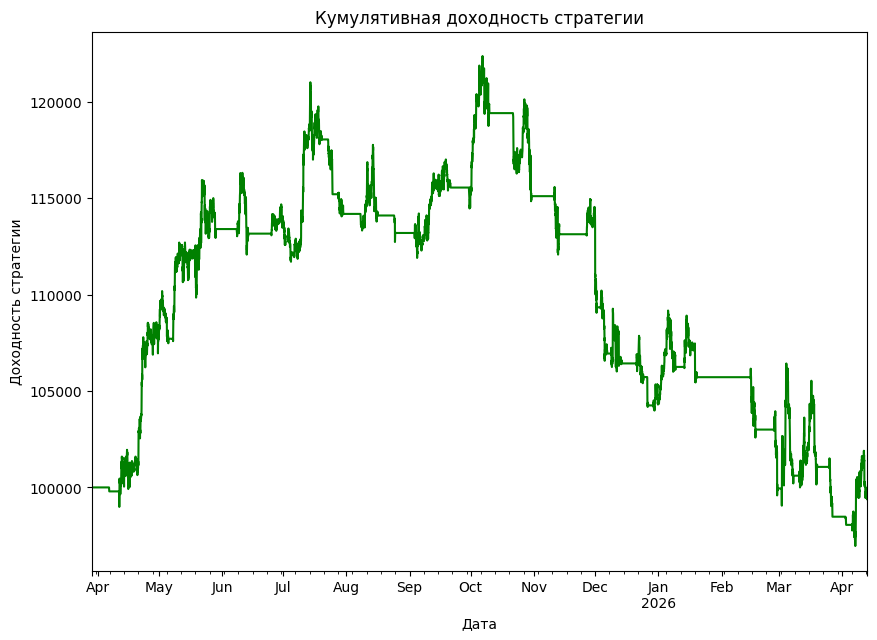

In [39]:
equity = initial_capital * (1 + portfolio['strategy_returns']).cumprod()
equity.plot(figsize=(10, 7), color='green')
plt.title('Кумулятивная доходность стратегии')
plt.xlabel('Дата')
plt.ylabel('Доходность стратегии')
plt.show()